In [19]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [46]:
centroid = [(-5, -5), (5, 5), (-2.5, 2.5), (2.5, -2.5)]
cluster_std = [1, 1, 1, 1]

In [47]:
X, y = make_blobs(n_samples=100, n_features=2, cluster_std=cluster_std, centers=centroid, random_state=2)

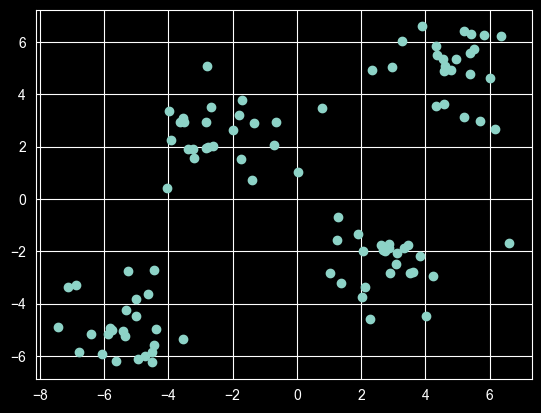

In [48]:
plt.scatter(X[:, 0], X[:, 1])

In [63]:
import  random

class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, X):
        random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            """Assign cluster"""
            cluster_group = self.assign_clusters(X)
            old_centroid = self.centroids

            self.centroids = self.move_centroids(X, cluster_group)

            """check finish"""
            if (old_centroid == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self, X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row - centroid, row - centroid)))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centrids = []

        cluster_type = np.unique(cluster_group)

        for type in cluster_type:
            new_centrids.append(X[cluster_group == type].mean(axis=0))

        return np.array(new_centrids)

In [64]:
km = KMeans(n_clusters=4, max_iter=100)

In [65]:
y_means = km.fit_predict(X)

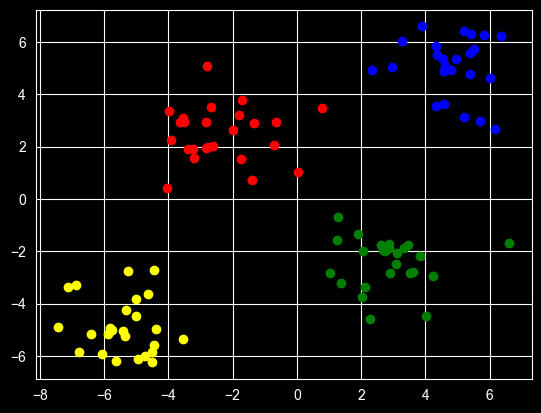

In [66]:
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], c='red')
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], c='blue')
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], c='green')
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1], c='yellow')
plt.show()